<a href="https://colab.research.google.com/github/magicteamwinx/python-data-science-course-2026/blob/main/python_practice_10_2025.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Оцінювання наявності даної роботи буде враховувати як наявність самих візуалізацій (вони можуть незначно відрізнятися від прикладів, але повинні змістовно відображати суть задачі) та опис отриманих вами результатів. При наявності ЛИШЕ візуалізацій без роз'яснень, завдання не буде зараховане за наявне.

Під час виконання вам дозволено користуватися будь-якими зручними для вас Python бібліотеками для візуалізації.

# I. Receiving Data.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

1. (2б) Для виконання цієї лабораторної роботи Вам необхідно скористатися вибіркою titanic ([train.csv](https://www.kaggle.com/c/titanic/data?select=train.csv)). Зчитайте його та збережіть його у змінну, щоб у подальшому її використати для візуалізацій. Виведіть інформацію про кожну колонку, її індекс, тип та кількість непропущених значень та перші кілька рядків датафрейму.


In [ ]:

df = pd.read_csv('train.csv')

# Виведення інформації про колонки, індекси, типи та пропуски
df.info()

# Виведення перших кількох рядків датафрейму
display(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# IІ. Data Visualization.

2. (10б) Створіть pie chart, який би показував співвідношення виживших до загиблих.

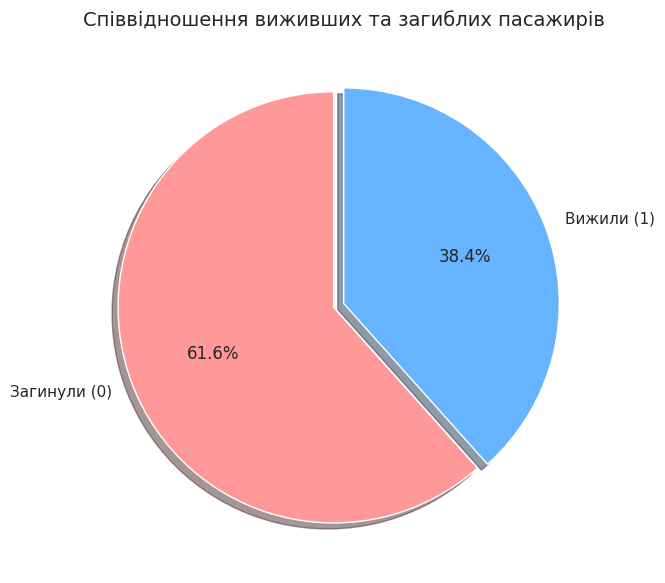

In [ ]:
# Підготовка даних
survived_counts = df['Survived'].value_counts()
labels = ['Загинули (0)', 'Вижили (1)']
colors = ['#ff9999', '#66b3ff']

# Побудова графіка
plt.figure(figsize=(7, 7))
plt.pie(survived_counts, labels=labels, colors=colors, autopct='%1.1f%%',
        startangle=90, explode=(0.05, 0), shadow=True)
plt.title('Співвідношення виживших та загиблих пасажирів', fontsize=14)
plt.show()

Ця кругова діаграма демонструє загальну статистику трагедії. Близько 61.6% пасажирів (із наявної навчальної вибірки) загинули, і лише 38.4% вдалося врятуватися. Це яскраво підтверджує масштабність катастрофи та низький загальний шанс на порятунок.

3. (20б) Створіть bar chart, який би показував співвідношення загиблих до виживших для кожної статі. Для groupby використовуйте атрибут as_index=False.


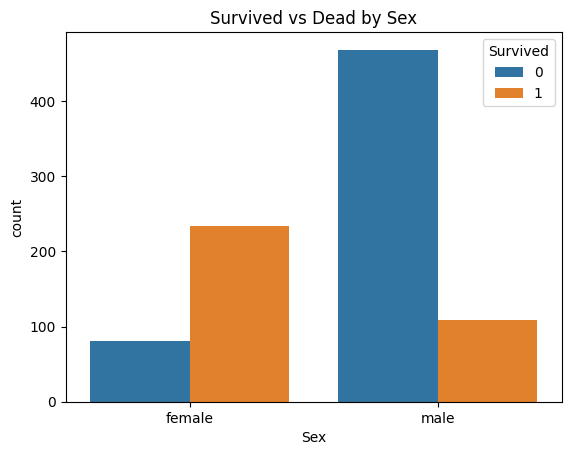

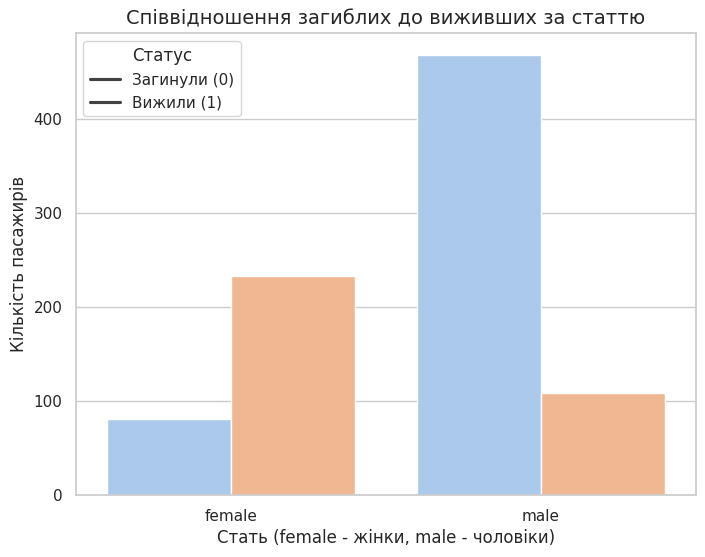

In [ ]:
# Групування даних згідно з умовою
gender_survived = df.groupby(['Sex', 'Survived'], as_index=False)['PassengerId'].count()
gender_survived.rename(columns={'PassengerId': 'Count'}, inplace=True)

# Побудова графіка
plt.figure(figsize=(8, 6))
sns.barplot(data=gender_survived, x='Sex', y='Count', hue='Survived', palette='pastel')
plt.title('Співвідношення загиблих до виживших за статтю', fontsize=14)
plt.xlabel('Стать (female - жінки, male - чоловіки)', fontsize=12)
plt.ylabel('Кількість пасажирів', fontsize=12)
plt.legend(title='Статус', labels=['Загинули (0)', 'Вижили (1)'])
plt.show()

На графіку чітко простежується застосування морського правила "жінки та діти перш за все". Серед жінок кількість тих, хто вижив, значно перевищує кількість загиблих. Натомість серед чоловіків ситуація кардинально протилежна — абсолютна більшість чоловіків на борту загинула.

4. (20б) Відобразіть кількість пропущених значень в датасеті по кожній із змінних.

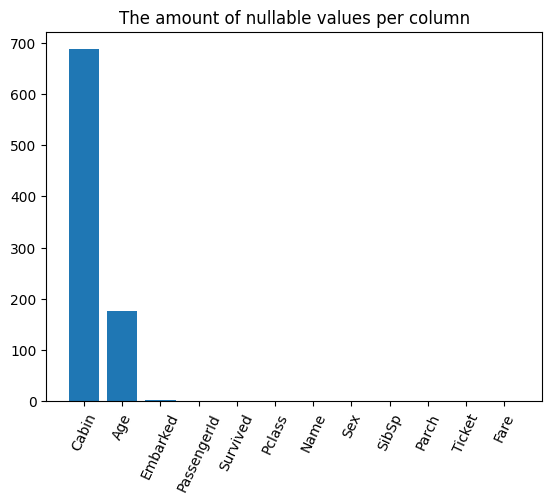

/tmp/ipykernel_29422/3983373165.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing_values.index, y=missing_values.values, palette='viridis')


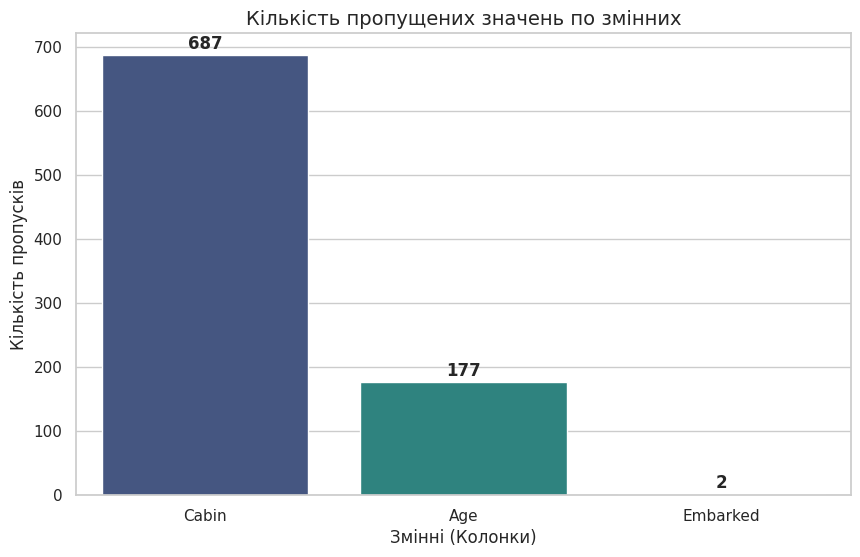

In [ ]:
# Підрахунок пропусків та фільтрація лише тих колонок, де вони є
missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0].sort_values(ascending=False)

# Побудова графіка
plt.figure(figsize=(10, 6))
sns.barplot(x=missing_values.index, y=missing_values.values, palette='viridis')
plt.title('Кількість пропущених значень по змінних', fontsize=14)
plt.xlabel('Змінні (Колонки)', fontsize=12)
plt.ylabel('Кількість пропусків', fontsize=12)

# Додавання підписів кількості над стовпчиками
for i, v in enumerate(missing_values.values):
    plt.text(i, v + 10, str(v), ha='center', fontweight='bold')

plt.show()

Графік демонструє, які саме колонки містять неповні дані. Найбільше пропущених значень міститься у колонці Cabin (номер каюти) — 687 пропусків. Їх настільки багато, що цю колонку часто взагалі відкидають при побудові моделей машинного навчання. Також є 177 пропусків у колонці Age (вік), які зазвичай потрібно заповнювати медіаною. У колонці Embarked (порт посадки) не вистачає всього 2 записів.




5. (10б) Побудуйте наступний графік, дайте йому назву та опишіть, що власне на них відображається.

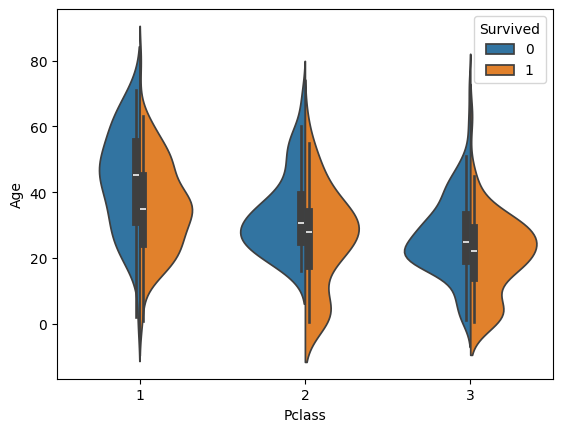

/tmp/ipykernel_29422/526104056.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Pclass', y='Age', palette='Set2')


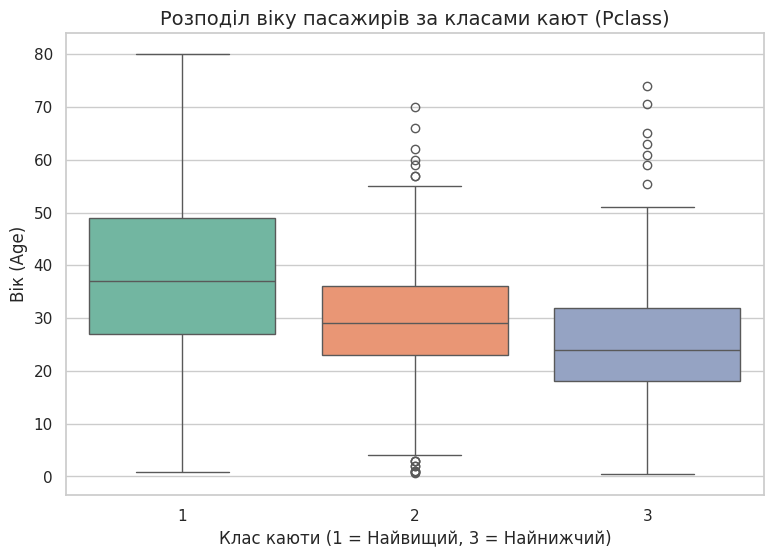

In [ ]:
# Побудова графіка
plt.figure(figsize=(9, 6))
sns.boxplot(data=df, x='Pclass', y='Age', palette='Set2')
plt.title('Розподіл віку пасажирів за класами кают (Pclass)', fontsize=14)
plt.xlabel('Клас каюти (1 = Найвищий, 3 = Найнижчий)', fontsize=12)
plt.ylabel('Вік (Age)', fontsize=12)
plt.show()

На цьому графіку (Boxplot) відображено розподіл віку пасажирів залежно від класу їхнього квитка. Можна помітити логічну тенденцію: пасажири 1-го класу в середньому є найстаршими (медіана близько 37 років), тоді як у 3-му класі подорожувало найбільше молоді (медіана близько 24 років). Точки за межами "вусиків" вказують на статистичні викиди — наприклад, дуже літніх людей, які подорожували 2-м та 3-м класами

6. (13б) Побудуйте графік розподілу частот по віку пасажирів.


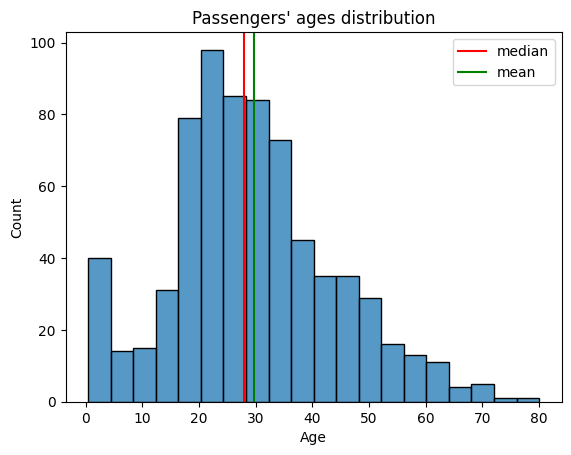

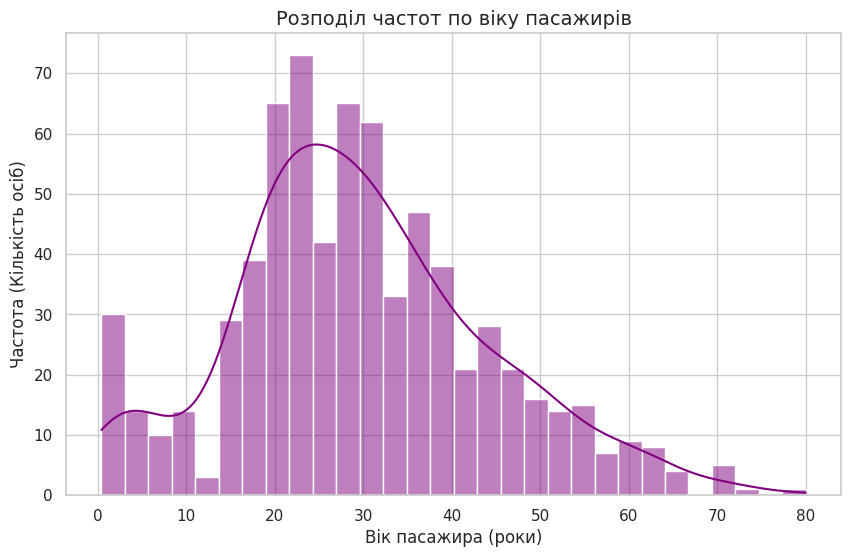

In [ ]:
# Побудова гістограми з кривою щільності (KDE)
plt.figure(figsize=(10, 6))
sns.histplot(df['Age'].dropna(), bins=30, kde=True, color='purple')
plt.title('Розподіл частот по віку пасажирів', fontsize=14)
plt.xlabel('Вік пасажира (роки)', fontsize=12)
plt.ylabel('Частота (Кількість осіб)', fontsize=12)
plt.show()

Гістограма показує, як розподілявся вік людей на борту. Розподіл наближений до нормального, але має витягнутий "хвіст" у правий бік (до старшого віку) і локальний пік на самому початку графіка (що свідчить про наявність значної кількості немовлят та маленьких дітей). Основна маса пасажирів — це молоді люди віком від 20 до 35 років.

7. (25б) Поставте бізнес-питання до даних. Дайте на нього відповідь за допомогою візуалізацій. Прокоментуйте отриману відповідь.

Як фінансовий статус пасажира (який визначається класом каюти — Pclass) вплинув на його шанси вижити під час евакуації? Чи справді власники найдорожчих квитків мали пріоритет під час посадки у рятувальні шлюпки?

/tmp/ipykernel_29422/2746066700.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Pclass', y='Survived', palette='muted', errorbar=None)


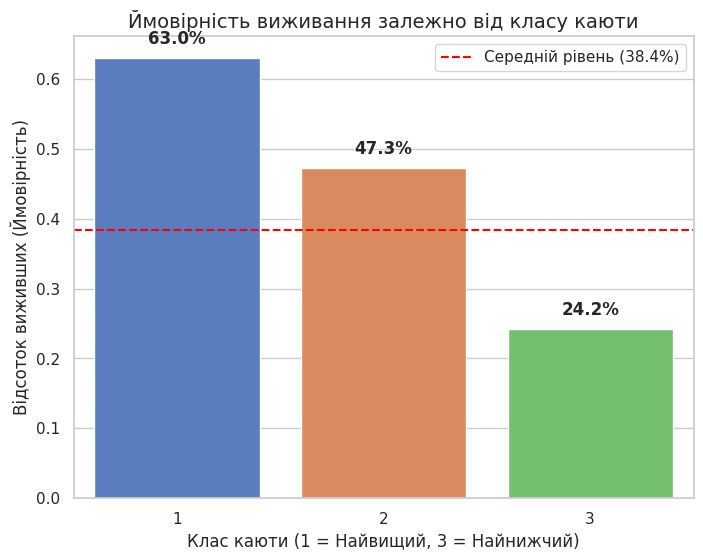

In [ ]:
# Побудова графіка (ймовірність виживання)
plt.figure(figsize=(8, 6))
sns.barplot(data=df, x='Pclass', y='Survived', palette='muted', errorbar=None)
plt.title('Ймовірність виживання залежно від класу каюти', fontsize=14)
plt.xlabel('Клас каюти (1 = Найвищий, 3 = Найнижчий)', fontsize=12)
plt.ylabel('Відсоток виживших (Ймовірність)', fontsize=12)

# Додавання горизонтальної лінії середнього рівня виживання
mean_survival = df['Survived'].mean()
plt.axhline(mean_survival, color='red', linestyle='--', label=f'Середній рівень ({mean_survival:.1%})')
plt.legend()

# Додавання підписів на стовпчики
survival_rates = df.groupby('Pclass')['Survived'].mean()
for i, rate in enumerate(survival_rates):
    plt.text(i, rate + 0.02, f'{rate:.1%}', ha='center', fontweight='bold')

plt.show()

Локація кают вищих класів (ближче до верхніх палуб), пріоритетний доступ до інформації від екіпажу та перевага під час посадки у шлюпки безпосередньо залежали від вартості придбаного квитка.

# Вітаю! Ви велика(ий) молодець, що впоралась(вся). Похваліть себе та побалуйте чимось приємним. Я Вами пишаюся.

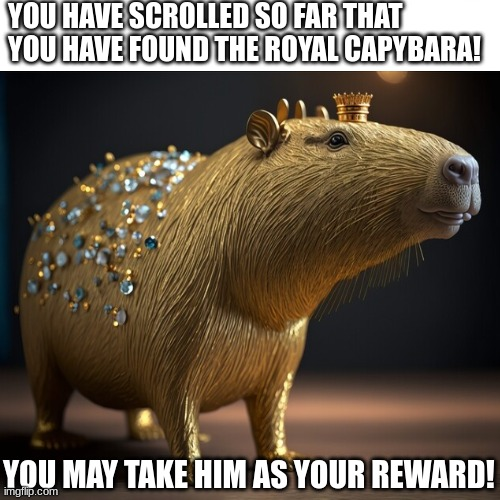